# Crime Enriched Modeling

## Setup & load

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
crime = pd.read_csv(r"/Users/veer.pth/Desktop/Sem 5/Data Science 3/DTSC-3602 Group 12 Project/data/crime_enriched.csv")

crime.head()

/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/1961362711.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv(r"/Users/veer.pth/Desktop/Sem 5/Data Science 3/DTSC-3602 Group 12 Project/data/crime_enriched.csv")


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,B23025_005_moe,B01003_001_moe,B19013_001_moe,B25077_001_moe,pct_bachelors_plus,unemployment_rate,DATE_OCC_dt,occ_hour,occ_month,occ_dayofweek
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,53.0,432.0,17660.0,26499.0,0.287518,0.071942,2020-11-07,8,11,5
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,94.0,584.0,11308.0,64778.0,0.298059,0.075253,2020-10-18,18,10,6
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,184.0,650.0,4776.0,69648.0,0.179627,0.087638,2020-10-30,12,10,4
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,57.0,602.0,11054.0,104577.0,0.436998,0.037946,2020-12-24,13,12,3
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,47.0,273.0,17720.0,26678.0,0.766377,0.037417,2020-09-29,18,9,1


In [10]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 62 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   DR_NO               1004991 non-null  int64  
 1   Date Rptd           1004991 non-null  object 
 2   DATE OCC            1004991 non-null  object 
 3   TIME OCC            1004991 non-null  int64  
 4   AREA                1004991 non-null  int64  
 5   AREA NAME           1004991 non-null  object 
 6   Rpt Dist No         1004991 non-null  int64  
 7   Part 1-2            1004991 non-null  int64  
 8   Crm Cd              1004991 non-null  int64  
 9   Crm Cd Desc         1004991 non-null  object 
 10  Mocodes             853372 non-null   object 
 11  Vict Age            1004991 non-null  int64  
 12  Vict Sex            860347 non-null   object 
 13  Vict Descent        860335 non-null   object 
 14  Premis Cd           1004975 non-null  float64
 15  Premis Desc    

In [11]:
print("rows:", crime.shape[0])
print(crime.columns.tolist()[:40])
print("Columns count:", len(crime.columns))
print("Duplicate column names:", crime.columns[crime.columns.duplicated()].tolist())

crime.columns = [c.strip() for c in crime.columns]

rows: 1004991
['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON', 'index_right', 'GEOID', 'edu_pop_25plus', 'edu_bachelors', 'edu_masters', 'edu_prof', 'edu_doctor', 'labor_force', 'employed', 'unemployed', 'pop_total', 'median_income']
Columns count: 62
Duplicate column names: []


## Filter to the five chosen reporting areas

In [12]:
target_areas = ["Central", "Hollywood", "Rampart", "Northeast", "Wilshire"]
# Note: check exact capitalization/spelling in your AREA NAME column
crime = crime[crime["AREA NAME"].isin(target_areas)].copy()
print("After area filter:", crime.shape)

After area filter: (260126, 62)


## ucr_mapping Dictionary (1=low,2=medium,3=high)

In [13]:
ucr_mapping = {
    "ARSON": 3,
    "ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER": 3,
    "ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT": 3,
    "ATTEMPTED ROBBERY": 3,
    "BATTERY - SIMPLE ASSAULT": 2,
    "BATTERY ON A FIREFIGHTER": 3,
    "BATTERY POLICE (SIMPLE)": 3,
    "BATTERY WITH SEXUAL CONTACT": 3,
    "BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM": 3,
    "BIGAMY": 1,
    "BIKE - ATTEMPTED STOLEN": 1,
    "BIKE - STOLEN": 1,
    "BLOCKING DOOR INDUCTION CENTER": 1,
    "BOAT - STOLEN": 2,
    "BOMB SCARE": 2,
    "BRANDISH WEAPON": 2,
    "BRIBERY": 2,
    "BUNCO, ATTEMPT": 2,
    "BUNCO, GRAND THEFT": 2,
    "BUNCO, PETTY THEFT": 1,
    "BURGLARY": 3,
    "BURGLARY FROM VEHICLE": 2,
    "BURGLARY FROM VEHICLE, ATTEMPTED": 2,
    "BURGLARY, ATTEMPTED": 3,
    "CHILD ABANDONMENT": 2,
    "CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT": 3,
    "CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT": 2,
    "CHILD ANNOYING (17YRS & UNDER)": 1,
    "CHILD NEGLECT (SEE 300 W.I.C.)": 1,
    "CHILD PORNOGRAPHY": 3,
    "CHILD STEALING": 3,
    "CONSPIRACY": 2,
    "CONTEMPT OF COURT": 1,
    "CONTRIBUTING": 1,
    "COUNTERFEIT": 2,
    "CREDIT CARDS, FRAUD USE ($950 & UNDER": 1,
    "CREDIT CARDS, FRAUD USE ($950.01 & OVER)": 2,
    "CRIMINAL HOMICIDE": 3,
    "CRIMINAL THREATS - NO WEAPON DISPLAYED": 2,
    "CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)": 3,
    "CRUELTY TO ANIMALS": 1,
    "DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER": 1,
    "DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01": 2,
    "DISCHARGE FIREARMS/SHOTS FIRED": 3,
    "DISHONEST EMPLOYEE - GRAND THEFT": 2,
    "DISHONEST EMPLOYEE - PETTY THEFT": 1,
    "DISHONEST EMPLOYEE ATTEMPTED THEFT": 1,
    "DISRUPT SCHOOL": 1,
    "DISTURBING THE PEACE": 1,
    "DOCUMENT FORGERY / STOLEN FELONY": 2,
    "DOCUMENT WORTHLESS ($200 & UNDER)": 1,
    "DOCUMENT WORTHLESS ($200.01 & OVER)": 2,
    "DRIVING WITHOUT OWNER CONSENT (DWOC)": 3,
    "DRUGS, TO A MINOR": 2,
    "DRUNK ROLL": 1,
    "DRUNK ROLL - ATTEMPT": 1,
    "EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)": 2,
    "EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)": 1,
    "EXTORTION": 3,
    "FAILURE TO DISPERSE": 1,
    "FAILURE TO YIELD": 1,
    "FALSE IMPRISONMENT": 3,
    "FALSE POLICE REPORT": 1,
    "FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)": 2,
    "FIREARMS RESTRAINING ORDER (FIREARMS RO)": 2,
    "GRAND THEFT / AUTO REPAIR": 2,
    "GRAND THEFT / INSURANCE FRAUD": 2,
    "HUMAN TRAFFICKING - COMMERCIAL SEX ACTS": 3,
    "HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE": 3,
    "ILLEGAL DUMPING": 1,
    "INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)": 3,
    "INCITING A RIOT": 2,
    "INDECENT EXPOSURE": 1,
    "INTIMATE PARTNER - AGGRAVATED ASSAULT": 3,
    "INTIMATE PARTNER - SIMPLE ASSAULT": 2,
    "KIDNAPPING": 3,
    "KIDNAPPING - GRAND ATTEMPT": 3,
    "LETTERS, LEWD  -  TELEPHONE CALLS, LEWD": 1,
    "LEWD CONDUCT": 1,
    "LEWD/LASCIVIOUS ACTS WITH CHILD": 3,
    "LYNCHING": 3,
    "LYNCHING - ATTEMPTED": 3,
    "MANSLAUGHTER, NEGLIGENT": 3,
    "ORAL COPULATION": 3,
    "OTHER ASSAULT": 2,
    "OTHER MISCELLANEOUS CRIME": 1,
    "PANDERING": 2,
    "PEEPING TOM": 1,
    "PETTY THEFT - AUTO REPAIR": 1,
    "PICKPOCKET": 2,
    "PICKPOCKET, ATTEMPT": 1,
    "PIMPING": 2,
    "PROWLER": 1,
    "PURSE SNATCHING": 2,
    "PURSE SNATCHING - ATTEMPT": 1,
    "RAPE, ATTEMPTED": 3,
    "RAPE, FORCIBLE": 3,
    "RECKLESS DRIVING": 1,
    "REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)": 1,
    "RESISTING ARREST": 2,
    "ROBBERY": 3,
    "SEX OFFENDER REGISTRANT OUT OF COMPLIANCE": 2,
    "SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ": 3,
    "SEXUAL PENETRATION W/FOREIGN OBJECT": 3,
    "SHOPLIFTING - ATTEMPT": 1,
    "SHOPLIFTING - PETTY THEFT ($950 & UNDER)": 1,
    "SHOPLIFTING-GRAND THEFT ($950.01 & OVER)": 2,
    "SHOTS FIRED AT INHABITED DWELLING": 3,
    "SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT": 3,
    "SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH": 3,
    "STALKING": 2,
    "TELEPHONE PROPERTY - DAMAGE": 1,
    "THEFT FROM MOTOR VEHICLE - ATTEMPT": 1,
    "THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)": 2,
    "THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)": 1,
    "THEFT FROM PERSON - ATTEMPT": 2,
    "THEFT OF IDENTITY": 2,
    "THEFT PLAIN - ATTEMPT": 1,
    "THEFT PLAIN - PETTY ($950 & UNDER)": 1,
    "THEFT, COIN MACHINE - ATTEMPT": 1,
    "THEFT, COIN MACHINE - PETTY ($950 & UNDER)": 1,
    "THEFT, PERSON": 2,
    "THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD": 2,
    "THREATENING PHONE CALLS/LETTERS": 1,
    "THROWING OBJECT AT MOVING VEHICLE": 2,
    "TILL TAP - GRAND THEFT ($950.01 & OVER)": 2,
    "TILL TAP - PETTY ($950 & UNDER)": 1,
    "TRAIN WRECKING": 3,
    "TRESPASSING": 1,
    "UNAUTHORIZED COMPUTER ACCESS": 2,
    "VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)": 2,
    "VANDALISM - MISDEAMEANOR ($399 OR UNDER)": 1,
    "VEHICLE - ATTEMPT STOLEN": 3,
    "VEHICLE - STOLEN": 3,
    "VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)": 2,
    "VIOLATION OF COURT ORDER": 1,
    "VIOLATION OF RESTRAINING ORDER": 2,
    "VIOLATION OF TEMPORARY RESTRAINING ORDER": 2,
    "WEAPONS POSSESSION/BOMBING": 3
}

In [14]:
print("Crime desc col:", "Crm Cd Desc" in crime.columns)
crime["Crm Cd Desc"] = crime["Crm Cd Desc"].astype(str).str.strip().str.upper()

Crime desc col: True


In [15]:
crime["severity"] = crime["Crm Cd Desc"].map(ucr_mapping)

crime

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,B01003_001_moe,B19013_001_moe,B25077_001_moe,pct_bachelors_plus,unemployment_rate,DATE_OCC_dt,occ_hour,occ_month,occ_dayofweek,severity
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,602.0,11054.0,104577.0,0.436998,0.037946,2020-12-24,13,12,3,2
7,201115217,10/29/2020 12:00:00 AM,07/07/2020 12:00:00 AM,1400,11,Northeast,1133,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,740.0,21600.0,60995.0,0.402187,0.085080,2020-07-07,14,7,1,3
10,240605846,02/06/2024 12:00:00 AM,06/20/2020 12:00:00 AM,1,6,Hollywood,657,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,529.0,7440.0,208990.0,0.197536,0.039474,2020-06-20,0,6,5,3
45,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,477.0,9728.0,208213.0,0.396351,0.074035,2020-08-17,12,8,0,2
55,210205056,01/12/2021 12:00:00 AM,10/14/2020 12:00:00 AM,1200,2,Rampart,237,2,354,THEFT OF IDENTITY,...,766.0,11031.0,203158.0,0.225521,0.066853,2020-10-14,12,10,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004948,250104175,02/12/2025 12:00:00 AM,02/12/2025 12:00:00 AM,340,1,Central,127,2,946,OTHER MISCELLANEOUS CRIME,...,519.0,43287.0,NaN,0.324407,0.120000,2025-02-12,3,2,2,1
1004959,251104105,02/09/2025 12:00:00 AM,02/09/2025 12:00:00 AM,1345,11,Northeast,1101,2,624,BATTERY - SIMPLE ASSAULT,...,6.0,NaN,NaN,NaN,0.000000,2025-02-09,13,2,6,2
1004960,250204086,01/27/2025 12:00:00 AM,01/27/2025 12:00:00 AM,1300,2,Rampart,249,2,930,CRIMINAL THREATS - NO WEAPON DISPLAYED,...,370.0,9296.0,NaN,0.280516,0.055341,2025-01-27,13,1,0,2
1004973,251104010,01/03/2025 12:00:00 AM,01/02/2025 12:00:00 AM,957,11,Northeast,1101,2,624,BATTERY - SIMPLE ASSAULT,...,6.0,NaN,NaN,NaN,0.000000,2025-01-02,9,1,3,2


In [16]:
unmapped = crime[crime["severity"].isna()]["Crm Cd Desc"].value_counts().head(25)
print("Number unmapped (top 25):")
print(unmapped)

Number unmapped (top 25):
Series([], Name: count, dtype: int64)


## Time features

In [17]:
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime["TIME OCC"] = pd.to_numeric(crime["TIME OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "TIME OCC"])  # necessary for time features
crime["occ_month"] = crime["DATE OCC"].dt.month
crime["occ_dayofweek"] = crime["DATE OCC"].dt.dayofweek  # 0=Mon
crime["occ_hour"] = (crime["TIME OCC"] // 100).astype(int)

/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3732277252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")


## Select BASE and CONTEXT features

In [18]:
base_features = [
  "AREA",             # numeric code or keep AREA NAME as categorical
  "AREA NAME",        # categorical
  "Rpt Dist No",
  "Part 1-2",
  "LAT", "LON",
  "occ_month", "occ_dayofweek", "occ_hour",
  "Vict Age", "Vict Sex", "Vict Descent",     # victim features (if present)
  "Premis Desc"                               # premise description if useful
]

context_features_extra = [
  "unemployment_rate",
  "pct_bachelors_plus",
  'edu_pop_25plus', 
  'edu_bachelors',
  'edu_masters', 
  'edu_prof', 
  'edu_doctor', 
  'labor_force', 
  'employed',
  'unemployed', 
  'pop_total', 
  'median_income', 
  'median_home_value'
]

In [19]:
# Only keep columns that exist
base_features = [c for c in base_features if c in crime.columns]
context_features_extra = [c for c in context_features_extra if c in crime.columns]

print("Using base features:", base_features)
print("Using context extras:", context_features_extra)

Using base features: ['AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'LAT', 'LON', 'occ_month', 'occ_dayofweek', 'occ_hour', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Desc']
Using context extras: ['unemployment_rate', 'pct_bachelors_plus', 'edu_pop_25plus', 'edu_bachelors', 'edu_masters', 'edu_prof', 'edu_doctor', 'labor_force', 'employed', 'unemployed', 'pop_total', 'median_income', 'median_home_value']


In [20]:
# Build two feature sets:
X_base = crime[base_features].copy()
X_context = crime[base_features + context_features_extra].copy()
y = crime["severity"].copy()

print("X_base shape:", X_base.shape)
print("X_context shape:", X_context.shape)

# Quick null checks
print("Base null percent per col:")
print(X_base.isna().mean().round(3))
print("Context null percent per col:")
print(X_context.isna().mean().round(3))

X_base shape: (260126, 13)
X_context shape: (260126, 26)
Base null percent per col:
AREA             0.000
AREA NAME        0.000
Rpt Dist No      0.000
Part 1-2         0.000
LAT              0.000
LON              0.000
occ_month        0.000
occ_dayofweek    0.000
occ_hour         0.000
Vict Age         0.000
Vict Sex         0.116
Vict Descent     0.116
Premis Desc      0.000
dtype: float64
Context null percent per col:
AREA                  0.000
AREA NAME             0.000
Rpt Dist No           0.000
Part 1-2              0.000
LAT                   0.000
LON                   0.000
occ_month             0.000
occ_dayofweek         0.000
occ_hour              0.000
Vict Age              0.000
Vict Sex              0.116
Vict Descent          0.116
Premis Desc           0.000
unemployment_rate     0.003
pct_bachelors_plus    0.010
edu_pop_25plus        0.003
edu_bachelors         0.003
edu_masters           0.003
edu_prof              0.003
edu_doctor            0.003
labor_force 

In [21]:
# Remove duplicated columns safely
X_base = X_base.loc[:, ~X_base.columns.duplicated()]
X_context = X_context.loc[:, ~X_context.columns.duplicated()]

## Build numeric/categorical lists robustly

In [22]:
# We'll impute simple missing values:
# For base
num_cols_base = X_base.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_base = X_base.select_dtypes(include=["object"]).columns.tolist()

# For context: numeric base + numeric context extras
num_context_candidates = X_context.select_dtypes(include=[np.number]).columns.tolist()
cat_context_candidates = X_context.select_dtypes(include=["object"]).columns.tolist()

num_cols_context = sorted(list(set(num_context_candidates)))
cat_cols_context = sorted(list(set(cat_context_candidates)))

print("numeric base cols:", num_cols_base)
print("categorical base cols:", cat_cols_base)
print("numeric context cols:", num_cols_context)
print("categorical context cols:", cat_cols_context)

numeric base cols: ['AREA', 'Rpt Dist No', 'Part 1-2', 'LAT', 'LON', 'occ_month', 'occ_dayofweek', 'occ_hour', 'Vict Age']
categorical base cols: ['AREA NAME', 'Vict Sex', 'Vict Descent', 'Premis Desc']
numeric context cols: ['AREA', 'LAT', 'LON', 'Part 1-2', 'Rpt Dist No', 'Vict Age', 'edu_bachelors', 'edu_doctor', 'edu_masters', 'edu_pop_25plus', 'edu_prof', 'employed', 'labor_force', 'median_home_value', 'median_income', 'occ_dayofweek', 'occ_hour', 'occ_month', 'pct_bachelors_plus', 'pop_total', 'unemployed', 'unemployment_rate']
categorical context cols: ['AREA NAME', 'Premis Desc', 'Vict Descent', 'Vict Sex']


## Preprocessors (correct types & imputers)

In [23]:
# Preprocessors:
numeric_imputer = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_imputer = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

In [24]:
# For MultinomialNB, we need non-negative features (use MinMax to make numeric features >=0)
numeric_minmax_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("minmax", MinMaxScaler())  # scales to [0,1]
])

# ColumnTransformers for base and context
base_preproc = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, num_cols_base),
        ("cat", categorical_imputer, cat_cols_base),
    ],
    remainder="drop",
    sparse_threshold=0
)

# For context preproc: include extra numeric context columns
num_cols_context = list(set(num_cols_base + [c for c in context_features_extra if c in X_context.columns]))
cat_cols_context = cat_cols_base  # same
context_preproc = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, num_cols_context),
        ("cat", categorical_imputer, cat_cols_context),
    ],
    remainder="drop",
    sparse_threshold=0
)

# For MultinomialNB pipelines we will build similar transformers but ensure non-negativity for numeric features:
base_preproc_mnb = ColumnTransformer(
    transformers=[
        ("num", numeric_minmax_pipeline, num_cols_base),
        ("cat", categorical_imputer, cat_cols_base),
    ],
    remainder="drop",
    sparse_threshold=0
)

context_preproc_mnb = ColumnTransformer(
    transformers=[
        ("num", numeric_minmax_pipeline, num_cols_context),
        ("cat", categorical_imputer, cat_cols_context),
    ],
    remainder="drop",
    sparse_threshold=0
)

## Model helper

In [25]:
from sklearn.model_selection import train_test_split

def evaluate_model(pipe, X, y, name):
  # split stratified
  X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
  )
  pipe.fit(X_train, y_train)
  preds = pipe.predict(X_test)
  print(f"\n--- {name} ---")
  print("Accuracy:", accuracy_score(y_test, preds))
  print("Macro F1:", f1_score(y_test, preds, average="macro"))
  print(classification_report(y_test, preds, zero_division=0))
  cm = confusion_matrix(y_test, preds, labels=[1,2,3])
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title(f"Confusion Matrix — {name}")
  plt.show()
  return pipe, X_test, y_test, preds

## Define pipelines

In [26]:
# Decision Tree (works with standard preproc)
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, class_weight="balanced", random_state=42)
pipe_dt_base = Pipeline([("pre", base_preproc), ("clf", dt)])
pipe_dt_context = Pipeline([("pre", context_preproc), ("clf", dt)])

# Multinomial Logistic Regression (multinomial)
lr = LogisticRegression(multi_class="multinomial", solver="saga", max_iter=2000, class_weight="balanced", random_state=42)
pipe_lr_base = Pipeline([("pre", base_preproc), ("clf", lr)])
pipe_lr_context = Pipeline([("pre", context_preproc), ("clf", lr)])

# k-NN
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
pipe_knn_base = Pipeline([("pre", base_preproc), ("clf", knn)])
pipe_knn_context = Pipeline([("pre", context_preproc), ("clf", knn)])

# MultinomialNB (needs non-negative features: use minmax preproc)
mnb = MultinomialNB()
pipe_mnb_base = Pipeline([("pre", base_preproc_mnb), ("clf", mnb)])
pipe_mnb_context = Pipeline([("pre", context_preproc_mnb), ("clf", mnb)])

## Train & evaluate


--- Decision Tree - BASE ---
Accuracy: 0.6247837619651713
Macro F1: 0.6050551849329812
              precision    recall  f1-score   support

           1       0.41      0.58      0.48     12182
           2       0.77      0.68      0.72     25256
           3       0.66      0.57      0.61     14588

    accuracy                           0.62     52026
   macro avg       0.61      0.61      0.61     52026
weighted avg       0.66      0.62      0.63     52026



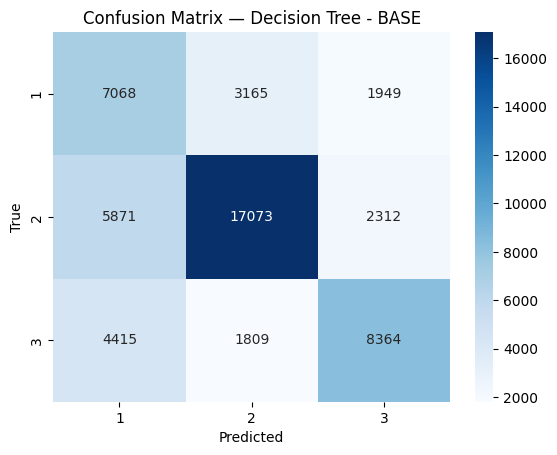


--- Decision Tree - CONTEXT ---
Accuracy: 0.6218621458501519
Macro F1: 0.6038412741780943
              precision    recall  f1-score   support

           1       0.41      0.58      0.48     12182
           2       0.79      0.66      0.72     25256
           3       0.64      0.60      0.62     14588

    accuracy                           0.62     52026
   macro avg       0.61      0.61      0.60     52026
weighted avg       0.66      0.62      0.63     52026



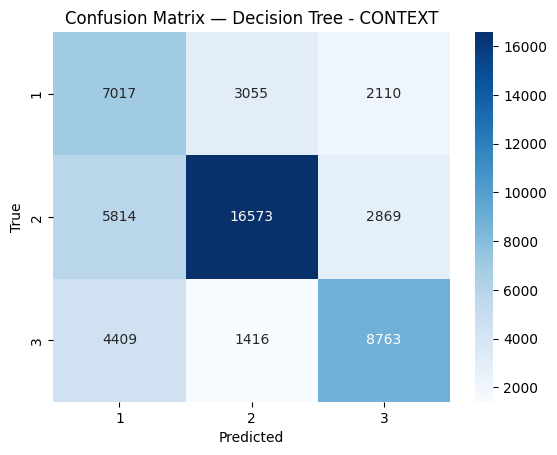

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- LogReg - BASE ---
Accuracy: 0.6582477991773344
Macro F1: 0.6243054333191312
              precision    recall  f1-score   support

           1       0.52      0.41      0.46     12182
           2       0.76      0.70      0.73     25256
           3       0.60      0.79      0.68     14588

    accuracy                           0.66     52026
   macro avg       0.63      0.63      0.62     52026
weighted avg       0.66      0.66      0.65     52026



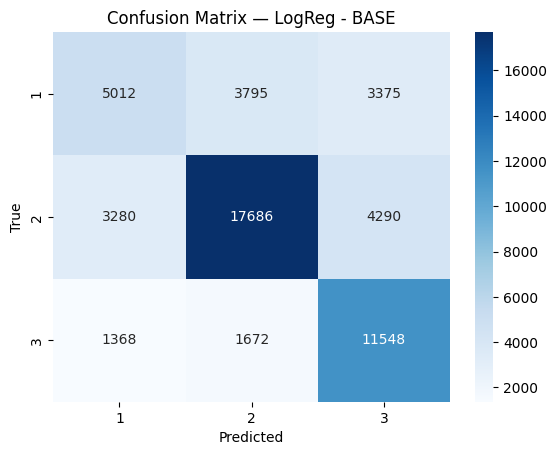

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- LogReg - CONTEXT ---
Accuracy: 0.6630146465228924
Macro F1: 0.6288588390592946
              precision    recall  f1-score   support

           1       0.52      0.42      0.46     12182
           2       0.77      0.71      0.74     25256
           3       0.61      0.79      0.69     14588

    accuracy                           0.66     52026
   macro avg       0.63      0.64      0.63     52026
weighted avg       0.67      0.66      0.66     52026



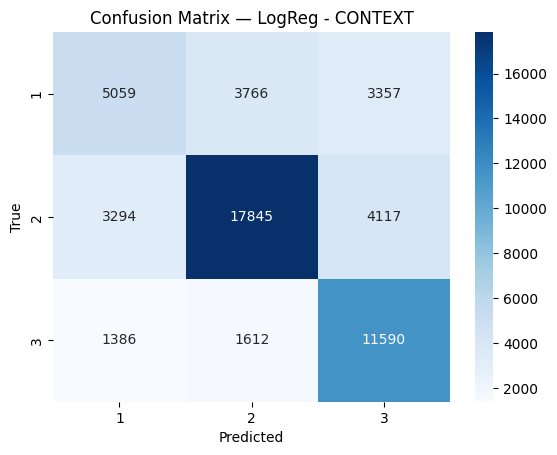


--- kNN - BASE ---
Accuracy: 0.6638988198208589
Macro F1: 0.6177020074898413
              precision    recall  f1-score   support

           1       0.53      0.38      0.44     12182
           2       0.71      0.81      0.75     25256
           3       0.66      0.65      0.66     14588

    accuracy                           0.66     52026
   macro avg       0.63      0.61      0.62     52026
weighted avg       0.65      0.66      0.65     52026



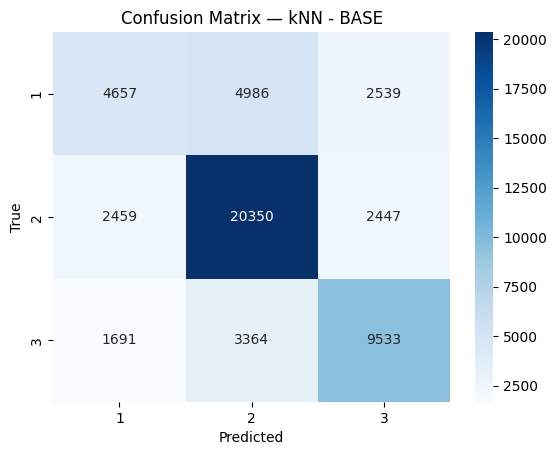


--- kNN - CONTEXT ---
Accuracy: 0.6577672702110483
Macro F1: 0.61004315149381
              precision    recall  f1-score   support

           1       0.52      0.37      0.43     12182
           2       0.70      0.81      0.75     25256
           3       0.65      0.64      0.65     14588

    accuracy                           0.66     52026
   macro avg       0.63      0.61      0.61     52026
weighted avg       0.65      0.66      0.65     52026



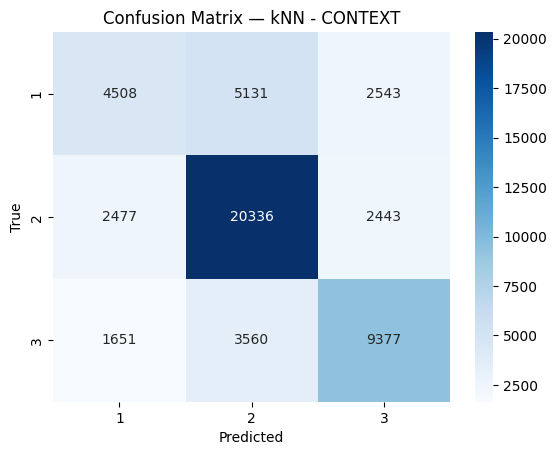


--- MultinomialNB - BASE ---
Accuracy: 0.621477722677123
Macro F1: 0.5529360447553807
              precision    recall  f1-score   support

           1       0.53      0.36      0.43     12182
           2       0.61      0.89      0.73     25256
           3       0.77      0.38      0.50     14588

    accuracy                           0.62     52026
   macro avg       0.64      0.54      0.55     52026
weighted avg       0.64      0.62      0.59     52026



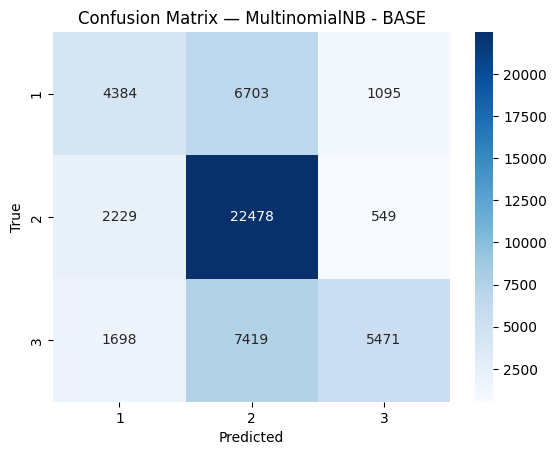


--- MultinomialNB - CONTEXT ---
Accuracy: 0.6214200592011686
Macro F1: 0.5530025916027741
              precision    recall  f1-score   support

           1       0.53      0.36      0.43     12182
           2       0.61      0.89      0.73     25256
           3       0.77      0.38      0.50     14588

    accuracy                           0.62     52026
   macro avg       0.64      0.54      0.55     52026
weighted avg       0.64      0.62      0.59     52026



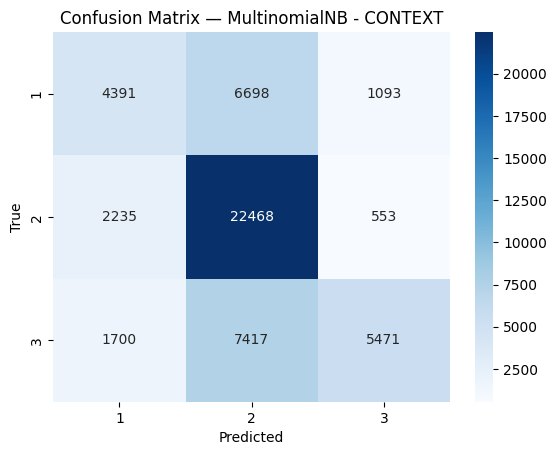

In [27]:
results = []
models = [
    ("Decision Tree - BASE", pipe_dt_base, X_base),
    ("Decision Tree - CONTEXT", pipe_dt_context, X_context),
    ("LogReg - BASE", pipe_lr_base, X_base),
    ("LogReg - CONTEXT", pipe_lr_context, X_context),
    ("kNN - BASE", pipe_knn_base, X_base),
    ("kNN - CONTEXT", pipe_knn_context, X_context),
    ("MultinomialNB - BASE", pipe_mnb_base, X_base),
    ("MultinomialNB - CONTEXT", pipe_mnb_context, X_context),
]

for name, pipe, X in models:
    try:
        trained_pipe, X_test, y_test, preds = evaluate_model(pipe, X, y, name)
        results.append((name, trained_pipe, X_test, y_test, preds))
    except Exception as e:
        print(f"Failed: {name} => {e}")

## Per-group fairness checks

### We'll compute per-group metrics for Vict Descent and Vict Sex (if present).

In [37]:
def per_group_metrics(y_test, preds, group_series, group_name):
    """
    Compute per-group metrics with severity=3 treated as the 'positive' class.
    Returns count, accuracy, precision, recall, F1, FPR, FNR for each group.
    Uses pre-computed predictions instead of calling pipe.predict again.
    """
    df = pd.DataFrame({
        "true": y_test.values,
        "pred": preds,
        group_name: group_series.values
    })

    POS = 3  # treat high-severity crimes as the positive class

    def metric_row(d):
        y_true = d["true"].values
        y_pred = d["pred"].values

        positive_true = (y_true == POS)
        positive_pred = (y_pred == POS)

        tp = np.sum(positive_true & positive_pred)
        tn = np.sum(~positive_true & ~positive_pred)
        fp = np.sum(~positive_true & positive_pred)
        fn = np.sum(positive_true & ~positive_pred)

        accuracy = np.mean(y_true == y_pred)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

        return pd.Series({
            "count": len(d),
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "FPR": fpr,
            "FNR": fnr
        })

    summary = (
        df.groupby(group_name)
          .apply(metric_row)
          .sort_values("count", ascending=False)
    )

    return summary


In [38]:
if results:
    # pick last successful model to show example metrics (or loop through results)
    name, pipe, X_test, y_test, preds = results[-1]
    print(f"\nPer-group metrics for model: {name}")
    # get groups aligned by index - X_test keeps original index
    if "Vict Descent" in crime.columns:
        groups = crime.loc[X_test.index, "Vict Descent"]
        print("\nBy Vict Descent:")
        display(per_group_metrics(y_test, preds, groups, "Vict Descent"))

    if "Vict Sex" in crime.columns:
        groups2 = crime.loc[X_test.index, "Vict Sex"]
        print("\nBy Vict Sex:")
        display(per_group_metrics(y_test, preds, groups2, "Vict Sex"))
else:
    print("No successful models to compute per-group metrics.")



Per-group metrics for model: MultinomialNB - CONTEXT

By Vict Descent:


/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3484516912.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metric_row)


,count,accuracy,precision,recall,f1,FPR,FNR
Vict Descent,,,,,,,
H,13234.0,0.615838,0.581848,0.110496,0.185722,0.025839,0.889504
W,11721.0,0.618719,0.820896,0.027054,0.052381,0.001239,0.972946
X,7303.0,0.514446,0.661765,0.027540,0.052879,0.004057,0.972460
B,6738.0,0.607450,0.531034,0.048673,0.089172,0.013189,0.951327
O,4054.0,0.573508,0.524590,0.038508,0.071749,0.008998,0.961492
A,1349.0,0.541883,0.245283,0.037464,0.065000,0.039920,0.962536
K,402.0,0.726368,0.000000,0.000000,0.000000,0.000000,1.000000
C,391.0,0.741688,0.000000,0.000000,0.000000,0.000000,1.000000
F,379.0,0.751979,0.000000,0.000000,0.000000,0.000000,1.000000



By Vict Sex:


/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3484516912.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metric_row)


,count,accuracy,precision,recall,f1,FPR,FNR
Vict Sex,,,,,,,
M,21585.0,0.588372,0.553493,0.098275,0.166914,0.024900,0.901725
F,17203.0,0.643609,0.815385,0.017851,0.034937,0.000843,0.982149
X,7125.0,0.513825,0.666667,0.012747,0.025016,0.001800,0.987253
H,7.0,0.857143,1.000000,1.000000,1.000000,0.000000,0.000000


In [29]:
rows = []

for name, pipe, X_test, y_test, preds in results:
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average="macro", zero_division=0)
    recall = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    rows.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

metrics_df = pd.DataFrame(rows)
print("\n=== MODEL PERFORMANCE TABLE ===")
print(metrics_df)


=== MODEL PERFORMANCE TABLE ===
                     Model  Accuracy  Precision    Recall  F1-Score
0     Decision Tree - BASE  0.624784   0.614723  0.609849  0.605055
1  Decision Tree - CONTEXT  0.621862   0.610746  0.610971  0.603841
2            LogReg - BASE  0.658248   0.627922  0.634435  0.624305
3         LogReg - CONTEXT  0.663015   0.631943  0.638779  0.628859
4               kNN - BASE  0.663899   0.631477  0.613839  0.617702
5            kNN - CONTEXT  0.657767   0.625149  0.606013  0.610043
6     MultinomialNB - BASE  0.621478   0.636862  0.541639  0.552936
7  MultinomialNB - CONTEXT  0.621420   0.636757  0.541698  0.553003


In [39]:
# Step 2: Build a fairness table for ALL trained models across one grouping (AREA for now)

fairness_rows = []

group_name = "AREA"
group_series_full = crime[group_name]

for name, pipe, X_test, y_test, preds in results:
    # extract the group labels for JUST the test indexes
    groups = group_series_full.loc[X_test.index]

    group_metrics = per_group_metrics(y_test, preds, groups, group_name)

    for g, row in group_metrics.iterrows():
        fairness_rows.append({
            "Model": name,
            "Group": g,
            **row.to_dict()
        })

fairness_df = pd.DataFrame(fairness_rows)
fairness_df


/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3484516912.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metric_row)
/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3484516912.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(metric_row)
/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_38799/3484516912.py:46: DeprecationWarning: DataFrameGr

,Model,Group,count,accuracy,precision,recall,f1,FPR,FNR
0,Decision Tree - BASE,1,14098.0,0.644914,0.643898,0.576672,0.608434,0.112572,0.423328
1,Decision Tree - BASE,6,10406.0,0.607246,0.616969,0.534046,0.572521,0.122352,0.465954
2,Decision Tree - BASE,7,9618.0,0.603972,0.678144,0.522692,0.590356,0.091907,0.477308
3,Decision Tree - BASE,2,9239.0,0.642710,0.690699,0.620887,0.653935,0.132247,0.379113
4,Decision Tree - BASE,11,8665.0,0.617080,0.691719,0.608231,0.647294,0.111600,0.391769
5,Decision Tree - CONTEXT,1,14098.0,0.646617,0.638395,0.605764,0.621652,0.121113,0.394236
6,Decision Tree - CONTEXT,6,10406.0,0.603498,0.588022,0.577540,0.582734,0.149322,0.422460
7,Decision Tree - CONTEXT,7,9618.0,0.601996,0.661283,0.535385,0.591711,0.101596,0.464615
8,Decision Tree - CONTEXT,2,9239.0,0.636757,0.651425,0.660175,0.655771,0.168024,0.339825
9,Decision Tree - CONTEXT,11,8665.0,0.609810,0.655855,0.616146,0.635381,0.133105,0.383854


In [42]:
# Mapping LAPD AREA numbers → official division names
area_name_map = {
    1: "Central",
    2: "Rampart",
    6: "Hollywood",
    7: "Wilshire",
    11: "Northeast",
}


In [45]:
# Split "Model" into model type and feature set ("BASE" / "CONTEXT")
fairness_df[["ModelType", "FeatureSet"]] = fairness_df["Model"].str.split(" - ", n=1, expand=True)



=== Decision Tree – BASE vs CONTEXT ===


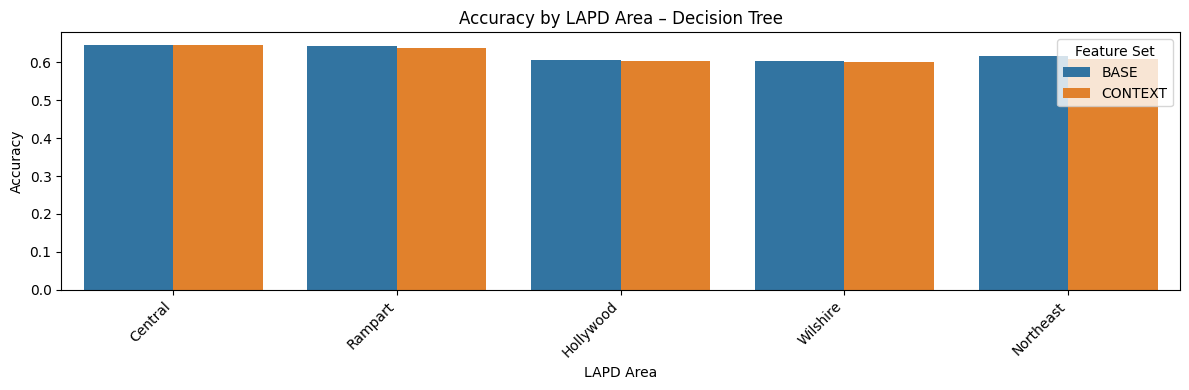

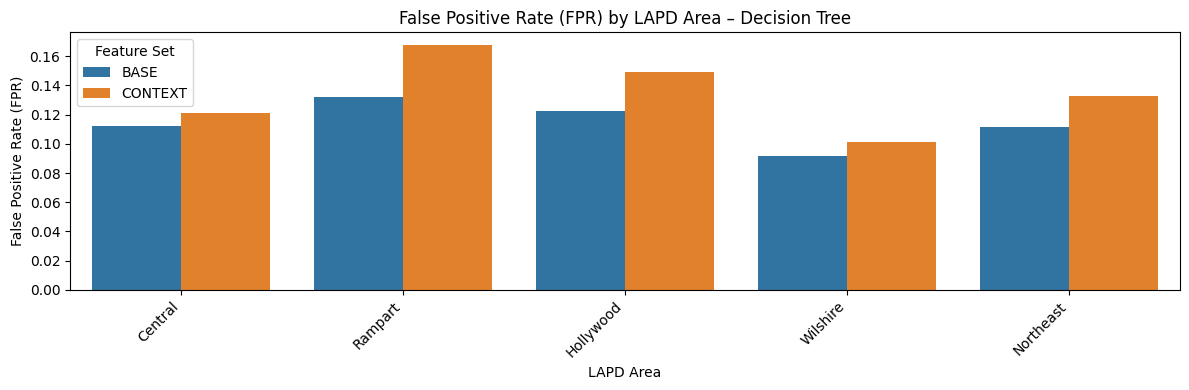

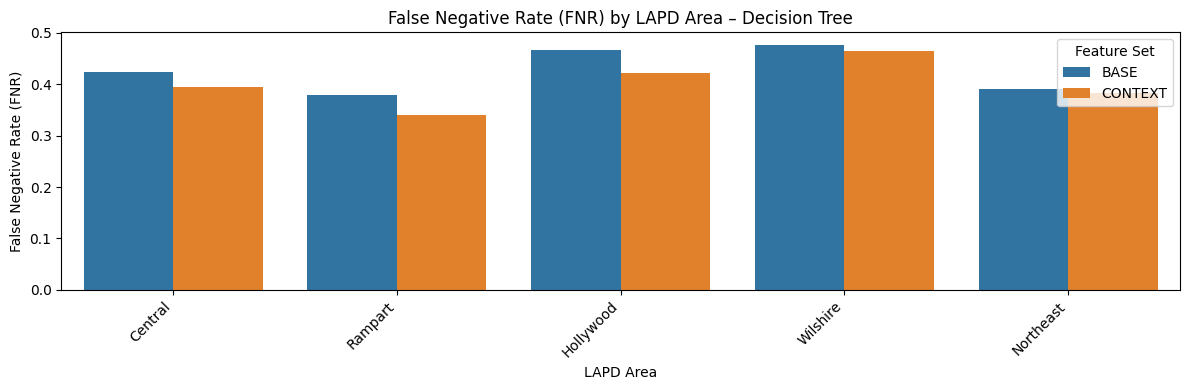


=== LogReg – BASE vs CONTEXT ===


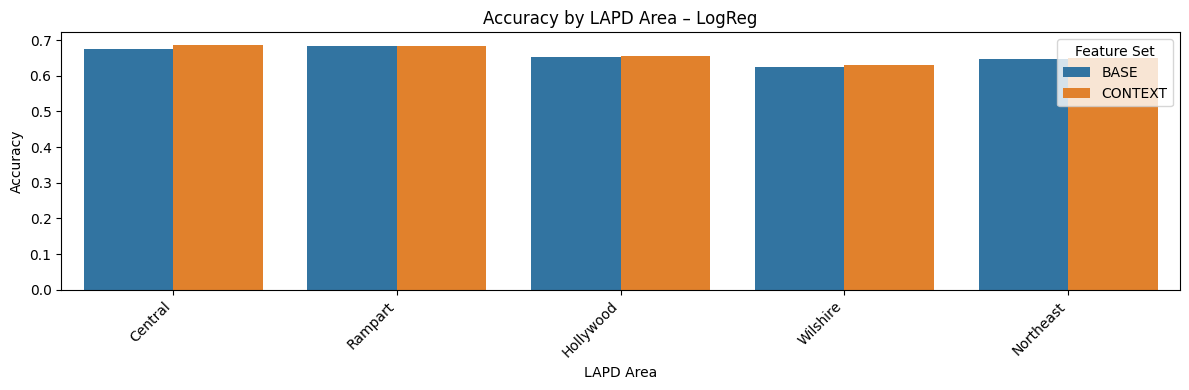

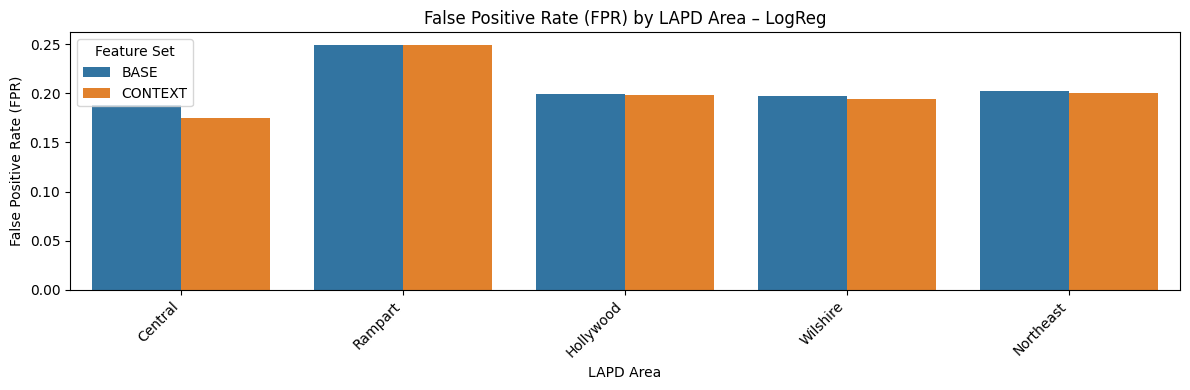

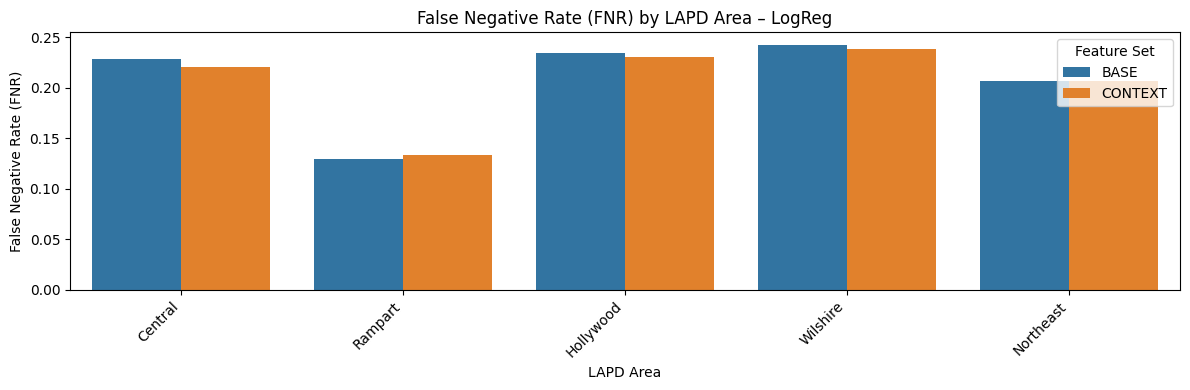


=== kNN – BASE vs CONTEXT ===


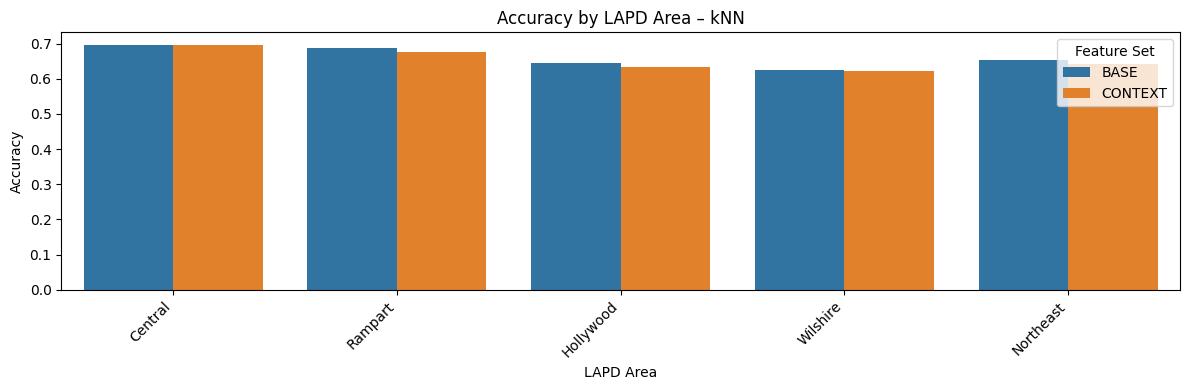

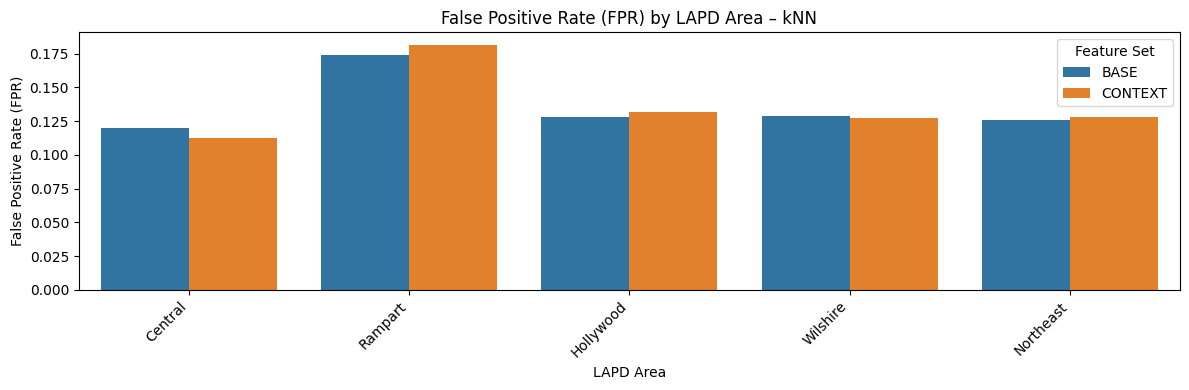

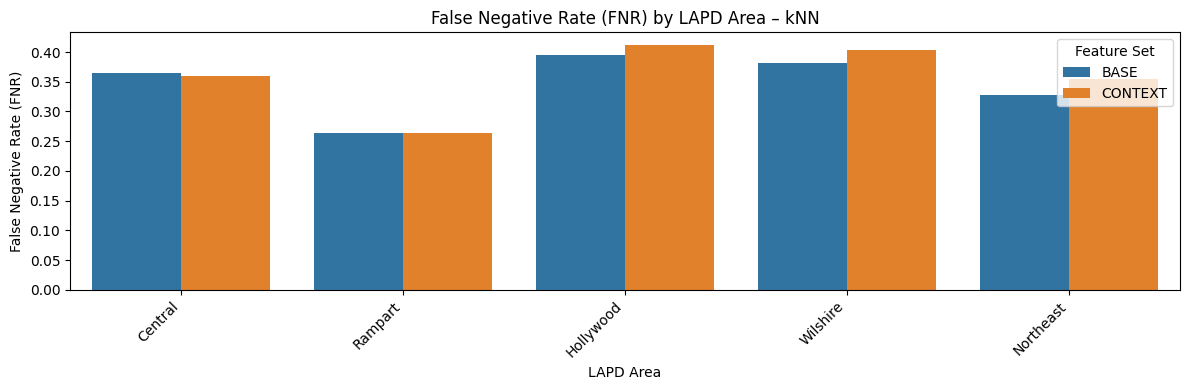


=== MultinomialNB – BASE vs CONTEXT ===


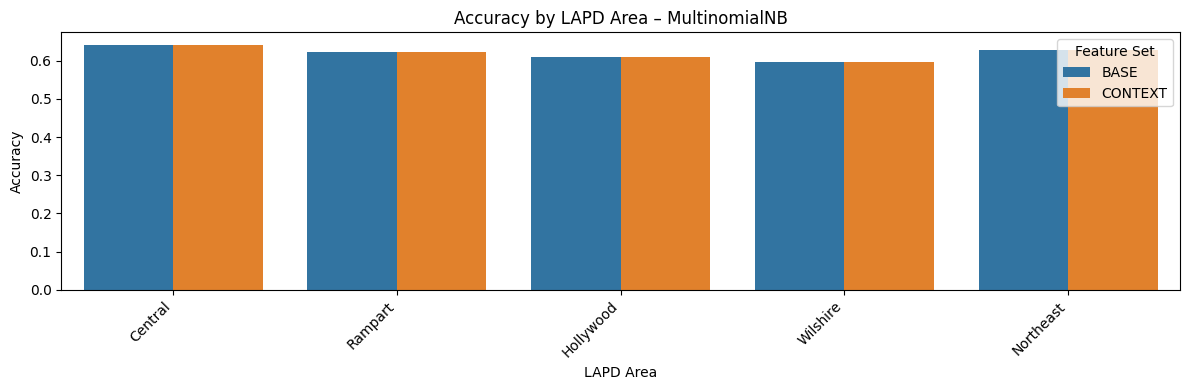

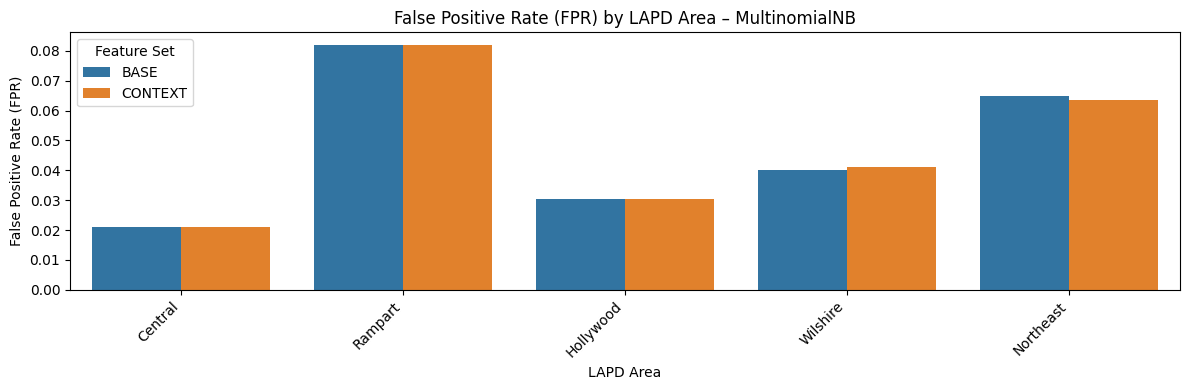

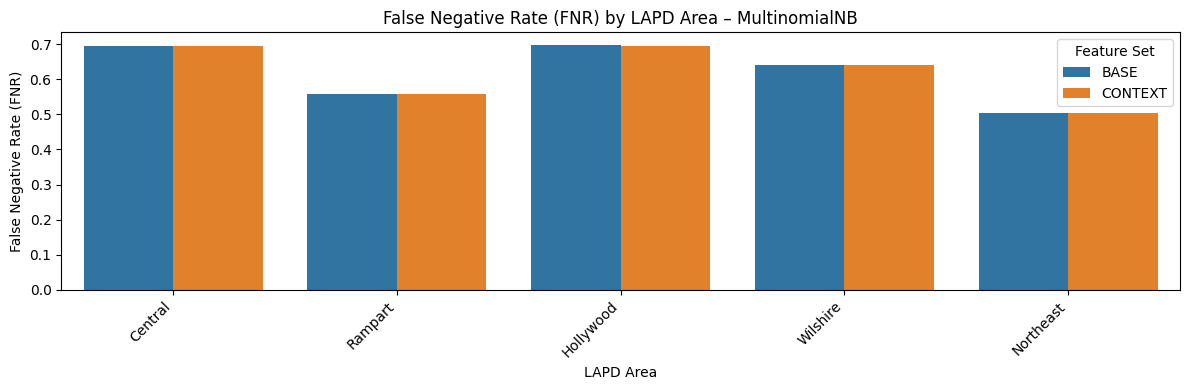

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["accuracy", "FPR", "FNR"]
metric_labels = {
    "accuracy": "Accuracy",
    "FPR": "False Positive Rate (FPR)",
    "FNR": "False Negative Rate (FNR)"
}

# Loop over each model type (Decision Tree, LogReg, KNN, MultinomialNB)
for model_type in fairness_df["ModelType"].unique():
    print(f"\n=== {model_type} – BASE vs CONTEXT ===")
    
    # Filter rows for this model type
    sub = fairness_df[fairness_df["ModelType"] == model_type].copy()
    
    # Attach human-readable area names
    sub["AreaName"] = sub["Group"].map(area_name_map)
    
    # Sort by numeric AREA for consistent ordering
    sub = sub.sort_values("Group")
    
    for metric in metrics:
        plt.figure(figsize=(12, 4))
        sns.barplot(
            data=sub,
            x="AreaName",
            y=metric,
            hue="FeatureSet"   # BASE vs CONTEXT side by side
        )
        plt.title(f"{metric_labels[metric]} by LAPD Area – {model_type}")
        plt.xlabel("LAPD Area")
        plt.ylabel(metric_labels[metric])
        plt.xticks(rotation=45, ha="right")
        plt.legend(title="Feature Set")
        plt.tight_layout()
        plt.show()


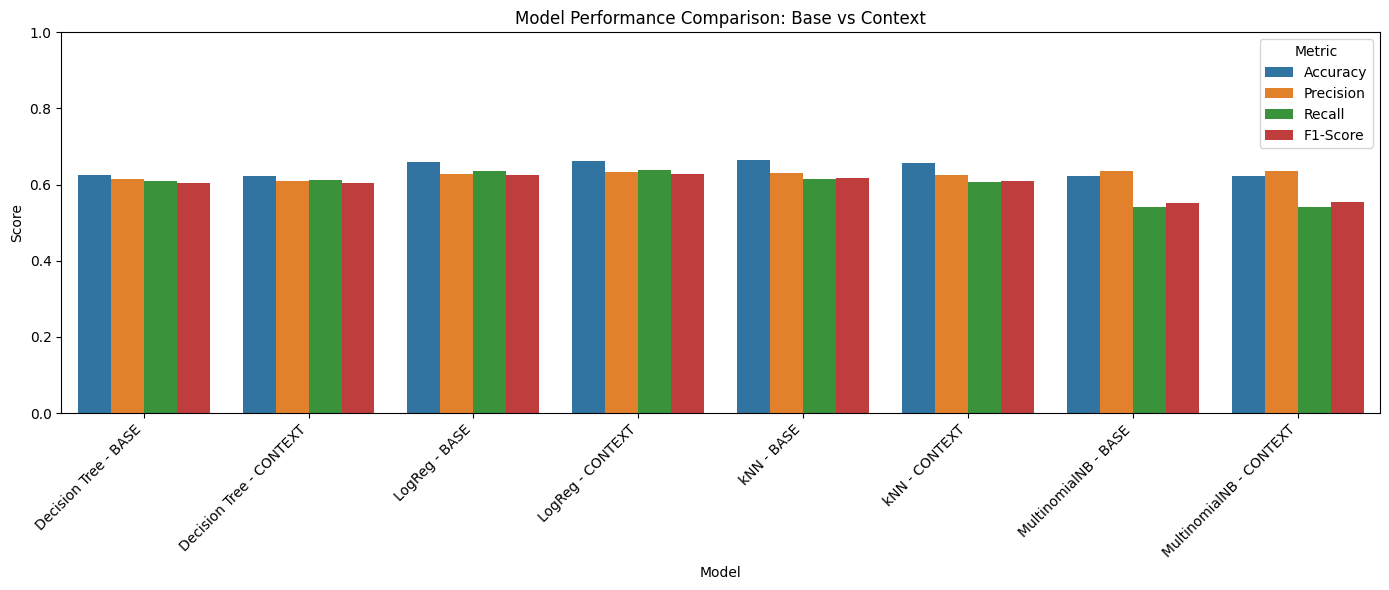

In [30]:
# Melt for easier plotting
metrics_melt = metrics_df.melt(id_vars="Model",
                               value_vars=["Accuracy","Precision","Recall","F1-Score"],
                               var_name="Metric",
                               value_name="Score")

plt.figure(figsize=(14,6))
sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric")
plt.xticks(rotation=45, ha="right")
plt.title("Model Performance Comparison: Base vs Context")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

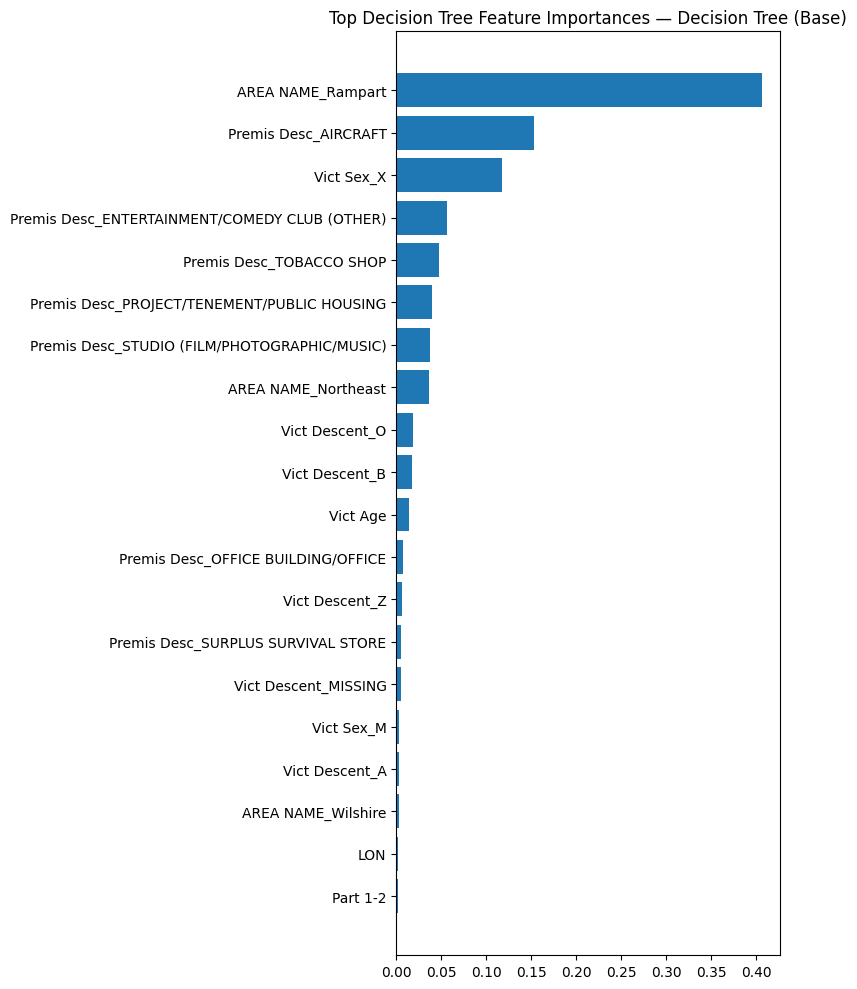

In [31]:
def plot_tree_importance(pipe, X, title):
    # Get feature names
    ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
    cat_cols = pipe.named_steps["pre"].transformers_[1][2]
    num_cols = pipe.named_steps["pre"].transformers_[0][2]

    feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

    importances = pipe.named_steps["clf"].feature_importances_
    idx = np.argsort(importances)[-20:]  # top 20

    plt.figure(figsize=(8,10))
    plt.barh(np.array(feature_names)[idx], importances[idx])
    plt.title(f"Top Decision Tree Feature Importances — {title}")
    plt.tight_layout()
    plt.show()

# Example: Use trained base model
plot_tree_importance(results[0][1], X_base, "Decision Tree (Base)")


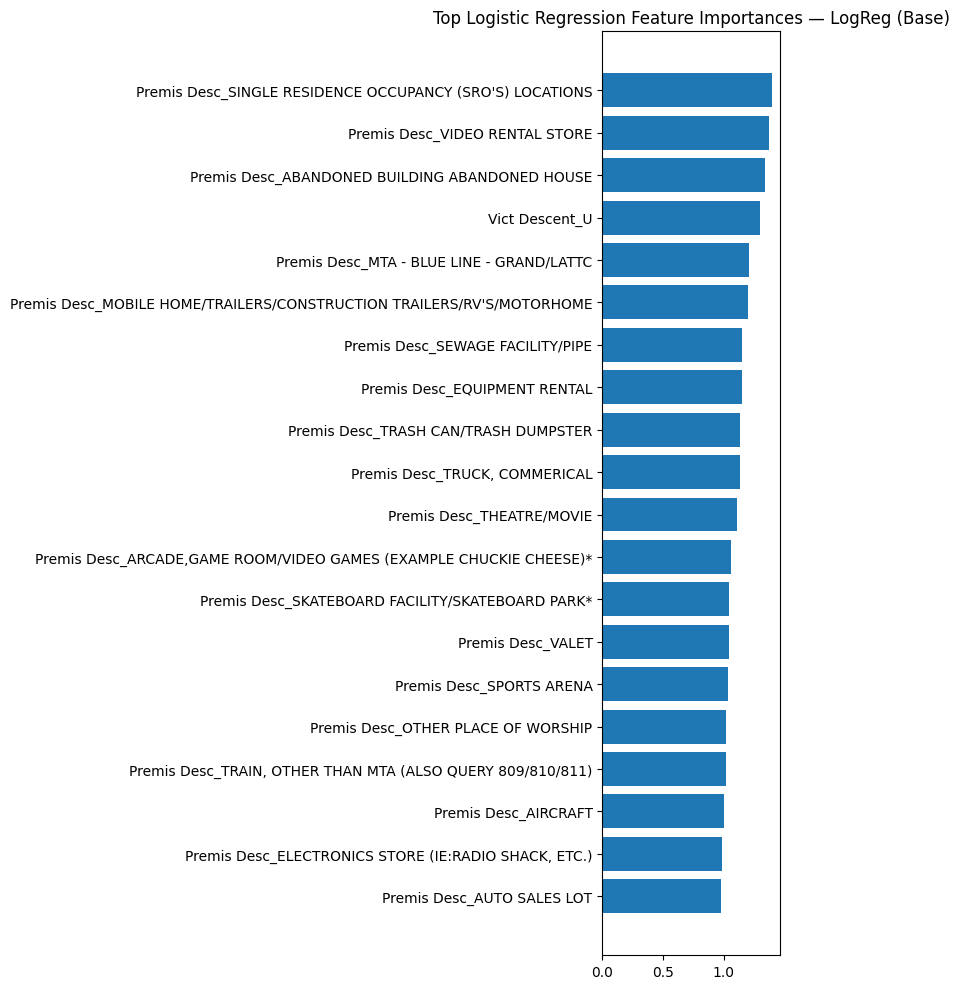

In [32]:
def plot_logreg_importance(pipe, X, title):
    clf = pipe.named_steps["clf"]

    # Extract feature names
    ohe = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
    cat_cols = pipe.named_steps["pre"].transformers_[1][2]
    num_cols = pipe.named_steps["pre"].transformers_[0][2]

    feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

    # Average absolute weights across classes
    coef = np.mean(np.abs(clf.coef_), axis=0)

    idx = np.argsort(coef)[-20:]  # top 20

    plt.figure(figsize=(8,10))
    plt.barh(np.array(feature_names)[idx], coef[idx])
    plt.title(f"Top Logistic Regression Feature Importances — {title}")
    plt.tight_layout()
    plt.show()

# Example:
plot_logreg_importance(results[2][1], X_base, "LogReg (Base)")


### Reason 1 — Crime severity is mostly determined by the crime itself (Crm Cd Desc)

Severity (1–3) is derived from: Violence level, Weapon used, Nature of the offense

Most of this comes from incident-level attributes, which you already have in the BASE model:

✔ Premis Desc

✔ Part 1-2

✔ Victim age/sex/descent

✔ Occurrence time

✔ Location area

Adding census context (education, unemployment, income) does not change the nature of the crime. Severity is not caused by socioeconomic context—only crime occurrence rates are.

Therefore, context features add very little signal.